In [19]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.rates.calibration import prepare_short_rate_data, estimate_vasicek_ols
from src.rates.vasicek import simulate_vasicek_exact

In [20]:
df = pd.read_csv(
    PROJECT_ROOT / "data/raw/ecb_aaa_spot_yield_curve.csv",
    parse_dates=["date"]
)

df.head()


,date,spot_3M,spot_1Y,spot_2Y,spot_5Y,spot_7Y,spot_10Y
0,2004-09-06,2.034172,2.298838,2.641262,3.457222,3.828505,4.209220
1,2004-09-07,2.040893,2.328891,2.679766,3.479518,3.839294,4.209626
2,2004-09-08,2.044384,2.346666,2.706542,3.507894,3.863753,4.228419
3,2004-09-09,2.037111,2.308988,2.646224,3.430628,3.789113,4.161872
4,2004-09-10,2.034645,2.271566,2.589654,3.374729,3.740559,4.120981


In [21]:
rate_cols = [col for col in df.columns if col.startswith("spot_")]
df[rate_cols] = df[rate_cols] / 100.0

In [22]:
short_rates = prepare_short_rate_data(
    df,
    date_col="date",
    rate_col="spot_3M"
)

short_rates.tail()

,date,short_rate
5568,2026-06-19,0.022216
5569,2026-06-22,0.022483
5570,2026-06-23,0.022279
5571,2026-06-24,0.022586
5572,2026-06-25,0.022823


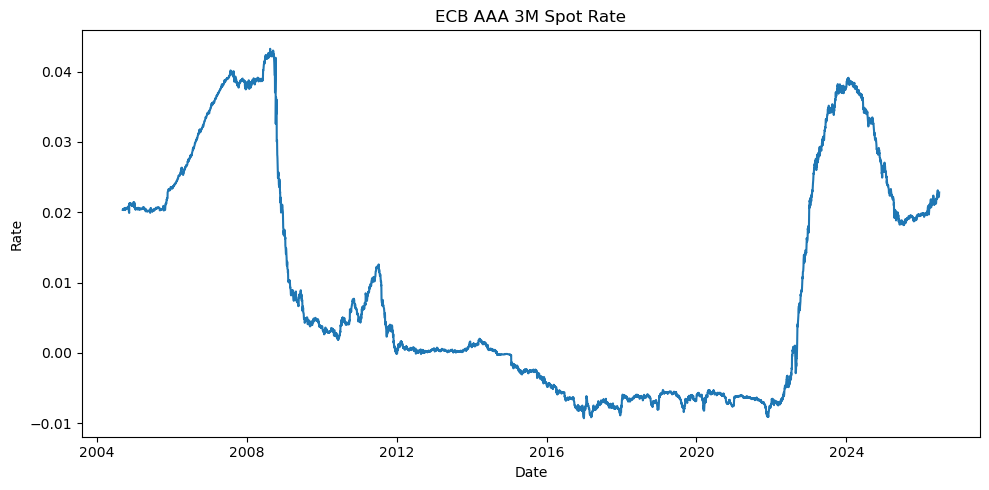

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(short_rates["date"], short_rates["short_rate"])
plt.title("ECB AAA 3M Spot Rate")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

In [24]:
params = estimate_vasicek_ols(
    short_rates["short_rate"],
    delta_t=1 / 252
)

params

VasicekParams(a=np.float64(0.03171912945162965), b=0.01289140501484594, sigma=np.float64(0.004371908977763116), phi=0.9998741383599249, c=1.622533378040994e-06, residual_std=0.000275387047198928, delta_t=0.003968253968253968)

In [25]:
print(f"a      = {params.a:.6f}")
print(f"b      = {params.b:.6f}")
print(f"sigma  = {params.sigma:.6f}")
print(f"phi    = {params.phi:.6f}")
print(f"c      = {params.c:.8f}")

a      = 0.031719
b      = 0.012891
sigma  = 0.004372
phi    = 0.999874
c      = 0.00000162


In [26]:
r0 = short_rates["short_rate"].iloc[-1]

sim = simulate_vasicek_exact(
    r0=r0,
    a=params.a,
    b=params.b,
    sigma=params.sigma,
    maturity=5.0,
    n_steps=252 * 5,
    n_paths=10_000,
    seed=42,
)

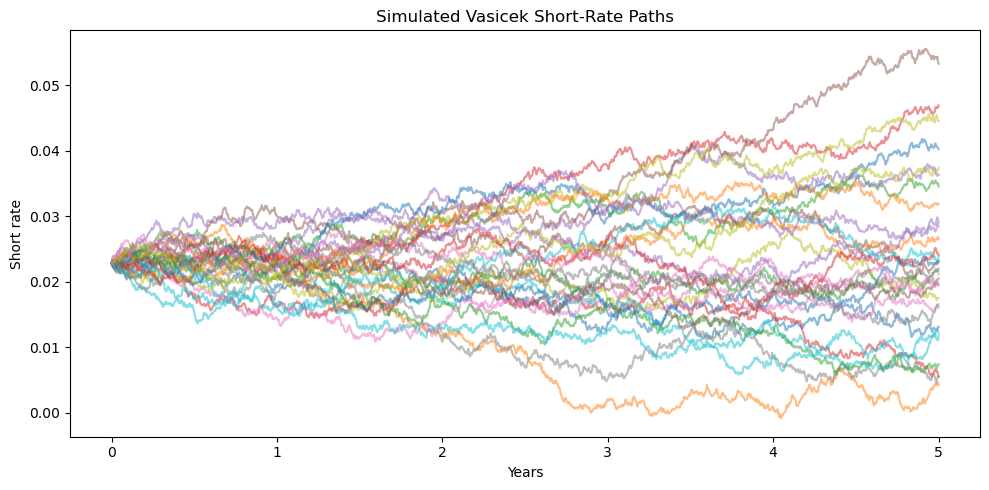

In [27]:
plt.figure(figsize=(10, 5))

for i in range(30):
    plt.plot(sim.time_grid, sim.rates[i], alpha=0.5)

plt.title("Simulated Vasicek Short-Rate Paths")
plt.xlabel("Years")
plt.ylabel("Short rate")
plt.tight_layout()
plt.show()

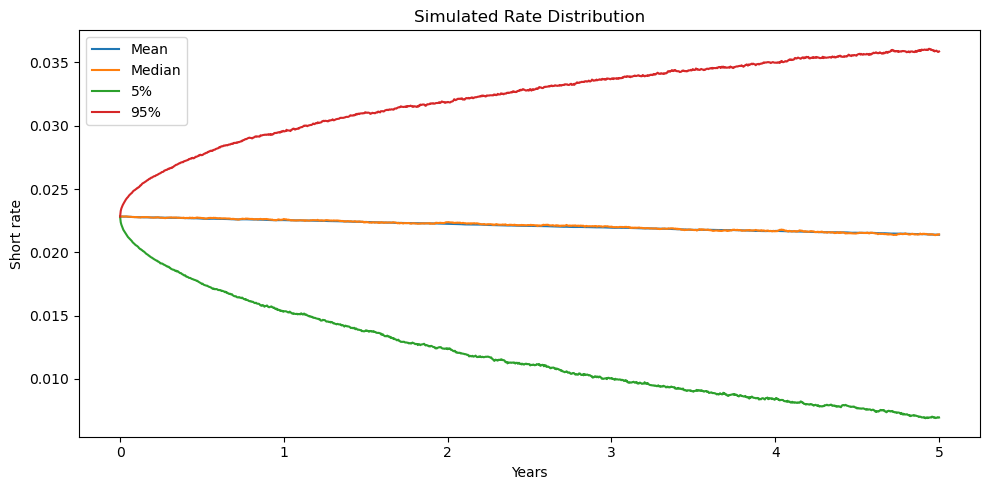

In [28]:
q05 = pd.DataFrame(sim.rates).quantile(0.05, axis=0)
q50 = pd.DataFrame(sim.rates).quantile(0.50, axis=0)
q95 = pd.DataFrame(sim.rates).quantile(0.95, axis=0)
mean_path = sim.rates.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(sim.time_grid, mean_path, label="Mean")
plt.plot(sim.time_grid, q50, label="Median")
plt.plot(sim.time_grid, q05, label="5%")
plt.plot(sim.time_grid, q95, label="95%")
plt.title("Simulated Rate Distribution")
plt.xlabel("Years")
plt.ylabel("Short rate")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
processed_dir = PROJECT_ROOT / "data/processed"
processed_dir.mkdir(parents=True, exist_ok=True)

short_rates.to_csv(
    processed_dir / "vasicek_short_rate_data.csv",
    index=False
)

In [30]:
#calibration window comparison
windows = {
    "Full sample": short_rates,
    "Last 10Y": short_rates[short_rates["date"] >= short_rates["date"].max() - pd.DateOffset(years=10)],
    "Last 5Y": short_rates[short_rates["date"] >= short_rates["date"].max() - pd.DateOffset(years=5)],
    "Post 2022": short_rates[short_rates["date"] >= "2022-01-01"],
}

rows = []

for name, data in windows.items():
    try:
        p = estimate_vasicek_ols(data["short_rate"], delta_t=1 / 252)
        rows.append({
            "window": name,
            "n_obs": len(data),
            "a": p.a,
            "b": p.b,
            "sigma": p.sigma,
            "phi": p.phi,
            "half_life_years": np.log(2) / p.a,
        })
    except Exception as e:
        rows.append({
            "window": name,
            "n_obs": len(data),
            "error": str(e),
        })

params_by_window = pd.DataFrame(rows)
params_by_window

,window,n_obs,a,b,sigma,phi,half_life_years
0,Full sample,5573,0.031719,0.012891,0.004372,0.999874,21.852655
1,Last 10Y,2551,0.003964,0.727525,0.004009,0.999984,174.859621
2,Last 5Y,1279,0.296758,0.038038,0.004991,0.998823,2.335729
3,Post 2022,1144,0.549645,0.033444,0.005222,0.997821,1.261081


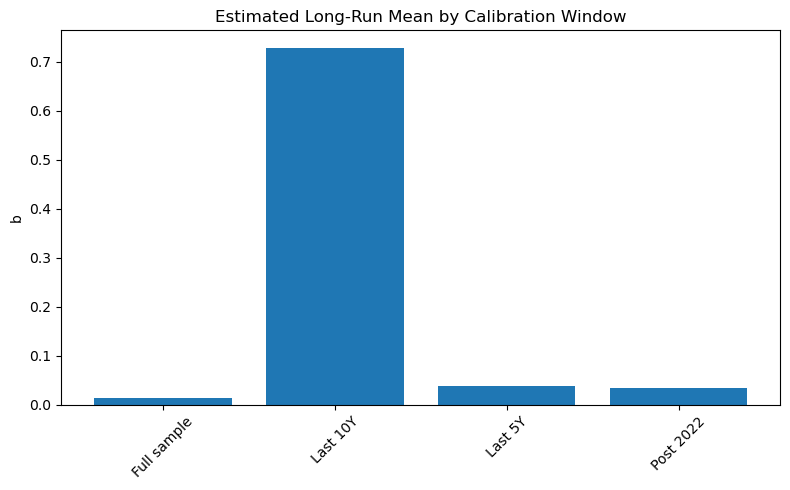

In [31]:
params_by_window_no_error = params_by_window.dropna(subset=["a", "b", "sigma"])

plt.figure(figsize=(8, 5))
plt.bar(params_by_window_no_error["window"], params_by_window_no_error["b"])
plt.title("Estimated Long-Run Mean by Calibration Window")
plt.ylabel("b")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

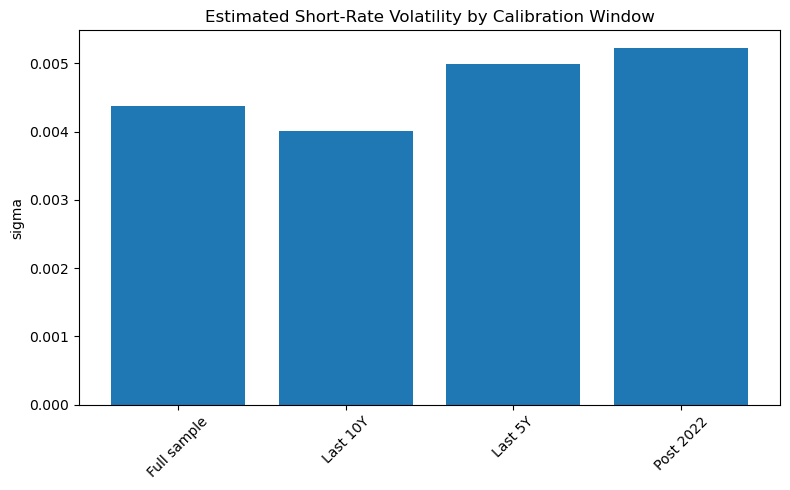

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(params_by_window_no_error["window"], params_by_window_no_error["sigma"])
plt.title("Estimated Short-Rate Volatility by Calibration Window")
plt.ylabel("sigma")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
#residual diagnostics
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

r_t = short_rates["short_rate"].iloc[:-1].to_numpy()
r_next = short_rates["short_rate"].iloc[1:].to_numpy()

X = sm.add_constant(r_t)
model = sm.OLS(r_next, X).fit()
residuals = model.resid

print(model.summary())

lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

jb_stat, jb_pvalue = jarque_bera(residuals)
print(f"Jarque-Bera statistic: {jb_stat:.4f}")
print(f"Jarque-Bera p-value: {jb_pvalue:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.895e+07
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:00:06   Log-Likelihood:                 37770.
No. Observations:                5572   AIC:                        -7.554e+04
Df Residuals:                    5570   BIC:                        -7.552e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.623e-06   4.27e-06      0.380      0.7

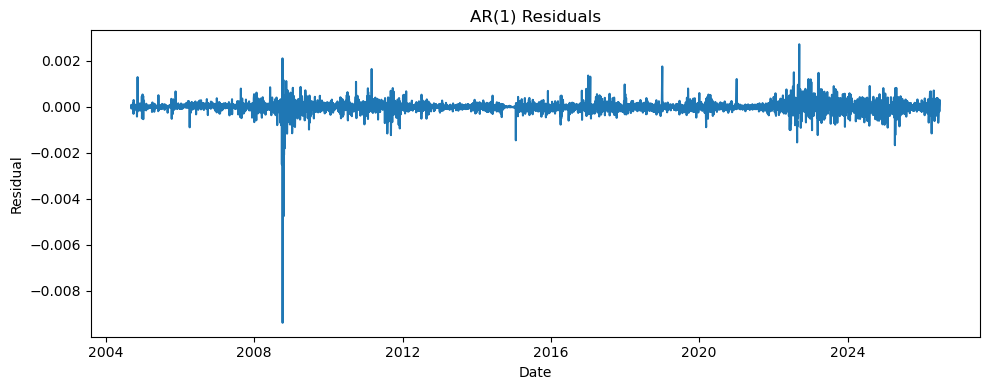

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(short_rates["date"].iloc[1:], residuals)
plt.title("AR(1) Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

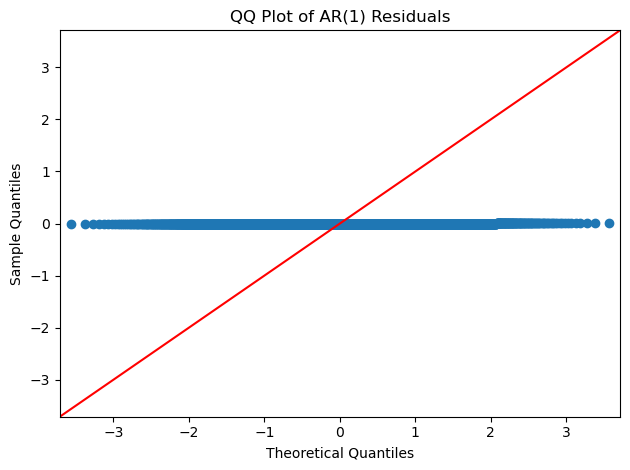

In [35]:
sm.qqplot(residuals, line="45")
plt.title("QQ Plot of AR(1) Residuals")
plt.tight_layout()
plt.show()

In [36]:
"""

Vasicek short-rate model.

The Vasicek model is useful because it is simple, analytically tractable,

and easy to estimate through its AR(1) representation.

However, empirical diagnostics on the ECB short-rate proxy show that the

Vasicek assumptions are too restrictive for the main exposure engine:

residuals are strongly non-normal, heavy-tailed, regime-dependent, and show

evidence of volatility clustering and higher-lag autocorrelation. In addition,

the model assumes constant volatility, one-factor Gaussian dynamics, and does

not fit the initial yield curve by construction.

For these reasons, Vasicek is not used as the final interest-rate model for

swap exposure simulation. The project upgrades the main exposure engine to a

Hull-White one-factor model, which remains tractable while allowing the model

to fit the initial term structure. Remaining issues such as volatility

clustering and tail risk are documented through stress testing and 

GARCH/EVT extensions.

"""

'\n\nVasicek short-rate model.\n\nThe Vasicek model is useful because it is simple, analytically tractable,\n\nand easy to estimate through its AR(1) representation.\n\nHowever, empirical diagnostics on the ECB short-rate proxy show that the\n\nVasicek assumptions are too restrictive for the main exposure engine:\n\nresiduals are strongly non-normal, heavy-tailed, regime-dependent, and show\n\nevidence of volatility clustering and higher-lag autocorrelation. In addition,\n\nthe model assumes constant volatility, one-factor Gaussian dynamics, and does\n\nnot fit the initial yield curve by construction.\n\nFor these reasons, Vasicek is not used as the final interest-rate model for\n\nswap exposure simulation. The project upgrades the main exposure engine to a\n\nHull-White one-factor model, which remains tractable while allowing the model\n\nto fit the initial term structure. Remaining issues such as volatility\n\nclustering and tail risk are documented through stress testing and \n\nGAR